In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [207]:
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [208]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Translation:", translation.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Translation: (71, 2)


In [209]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [210]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [211]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [212]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [213]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [214]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [215]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [216]:
orders.info()
customers.info()
order_items.info()
payments.info()
reviews.info()
products.info()
translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null 

In [217]:
print("ORDERS")
display(missing_values(orders))

print("CUSTOMERS")
display(missing_values(customers))

print("ORDER ITEMS")
display(missing_values(order_items))

print("PAYMENTS")
display(missing_values(payments))

print("REVIEWS")
display(missing_values(reviews))

print("PRODUCTS")
display(missing_values(products))

ORDERS


,Missing Values,Percentage
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


CUSTOMERS


,Missing Values,Percentage


ORDER ITEMS


...

,Missing Values,Percentage


REVIEWS


,Missing Values,Percentage
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


PRODUCTS


,Missing Values,Percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [218]:
print("Orders duplicates:", orders.duplicated().sum())
print("Customers duplicates:", customers.duplicated().sum())
print("Order Items duplicates:", order_items.duplicated().sum())
print("Payments duplicates:", payments.duplicated().sum())
print("Reviews duplicates:", reviews.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Translation duplicates:", translation.duplicated().sum())

Orders duplicates: 0
Customers duplicates: 0
Order Items duplicates: 0
Payments duplicates: 0
Reviews duplicates: 0
Products duplicates: 0
Translation duplicates: 0


In [219]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [220]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [221]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [222]:
products["product_category_name"].nunique()

73

In [223]:
products["product_category_name"].value_counts().head(15)

product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64

In [224]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [225]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])
   

In [226]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [227]:
orders = orders.drop_duplicates()
customers = customers.drop_duplicates()
order_items = order_items.drop_duplicates()
payments = payments.drop_duplicates()
reviews = reviews.drop_duplicates()
products = products.drop_duplicates()
translation = translation.drop_duplicates()

In [228]:
print("Unique Order IDs:", orders["order_id"].nunique())
print("Unique Customer IDs:", customers["customer_id"].nunique())
print("Unique Product IDs:", products["product_id"].nunique())

Unique Order IDs: 99441
Unique Customer IDs: 99441
Unique Product IDs: 32951


In [229]:
print("Orders rows:", len(orders))
print("Customers rows:", len(customers))
print("Products rows:", len(products))

Orders rows: 99441
Customers rows: 99441
Products rows: 32951


In [230]:
print("Duplicate Order IDs:", orders["order_id"].duplicated().sum())
print("Duplicate Customer IDs:", customers["customer_id"].duplicated().sum())
print("Duplicate Product IDs:", products["product_id"].duplicated().sum())

Duplicate Order IDs: 0
Duplicate Customer IDs: 0
Duplicate Product IDs: 0


In [231]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [232]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [233]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [234]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


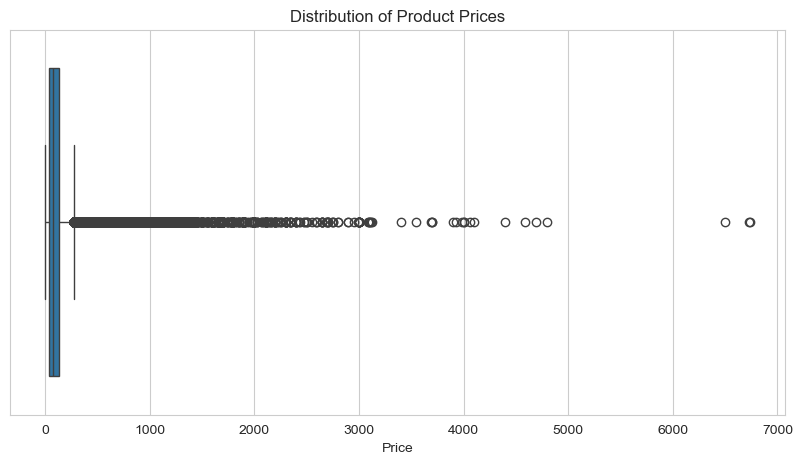

In [235]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=order_items["price"])

plt.title("Distribution of Product Prices")
plt.xlabel("Price")

plt.show()

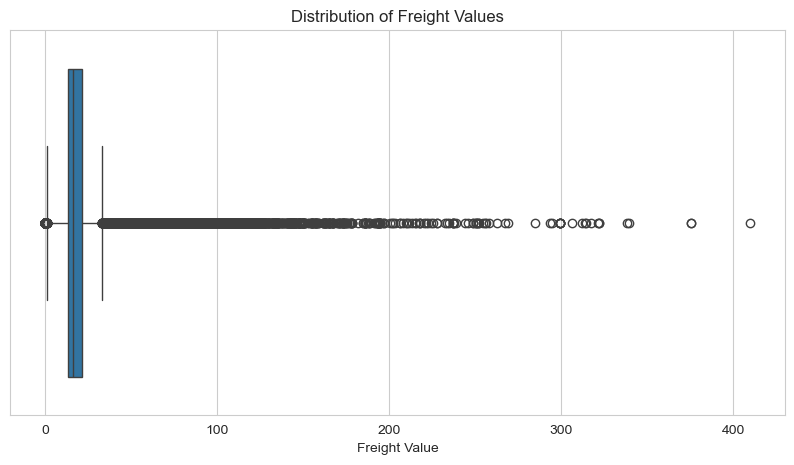

In [236]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=order_items["freight_value"])

plt.title("Distribution of Freight Values")
plt.xlabel("Freight Value")

plt.show()

In [237]:
sales_data = orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

In [238]:
sales_data = sales_data.merge(
    order_items[
        [
            "order_id",
            "product_id",
            "price",
            "freight_value"
        ]
    ],
    on="order_id",
    how="inner"
)

In [239]:
sales_data.shape

(112650, 9)

In [240]:
sales_data = sales_data.merge(
    products[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)

In [241]:
sales_data = sales_data.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [242]:
sales_data = sales_data.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [243]:
sales_data = sales_data.merge(
    customers[
        [
            "customer_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

In [244]:
sales_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,product_id,price,freight_value,product_category_name,product_category_name_english_x,product_category_name_english_y,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas,housewares,housewares,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,perfumery,perfumery,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,auto,auto,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,pet_shop,pet_shop,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,stationery,stationery,SP


In [245]:
sales_data.shape

(112650, 13)

In [246]:
sales_data["delivery_days"] = (
    sales_data["order_delivered_customer_date"]
    - sales_data["order_purchase_timestamp"]
).dt.days

In [247]:
sales_data["estimated_delivery_days"] = (
    sales_data["order_estimated_delivery_date"]
    - sales_data["order_purchase_timestamp"]
).dt.days

In [248]:
sales_data["delivery_difference"] = (
    sales_data["order_delivered_customer_date"]
    - sales_data["order_estimated_delivery_date"]
).dt.days

In [249]:
sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [250]:
sales_data[
    [
        "order_purchase_timestamp",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_difference",
        "purchase_month"
    ]
].head()

,order_purchase_timestamp,delivery_days,estimated_delivery_days,delivery_difference,purchase_month
0,2017-10-02 10:56:33,8.0,15,-8.0,2017-10
1,2018-07-24 20:41:37,13.0,19,-6.0,2018-07
2,2018-08-08 08:38:49,9.0,26,-18.0,2018-08
3,2017-11-18 19:28:06,13.0,26,-13.0,2017-11
4,2018-02-13 21:18:39,2.0,12,-10.0,2018-02


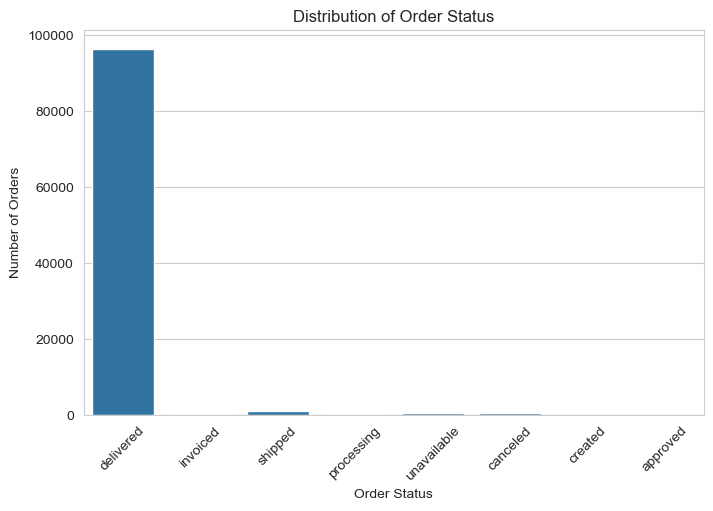

In [251]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="order_status"
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [252]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

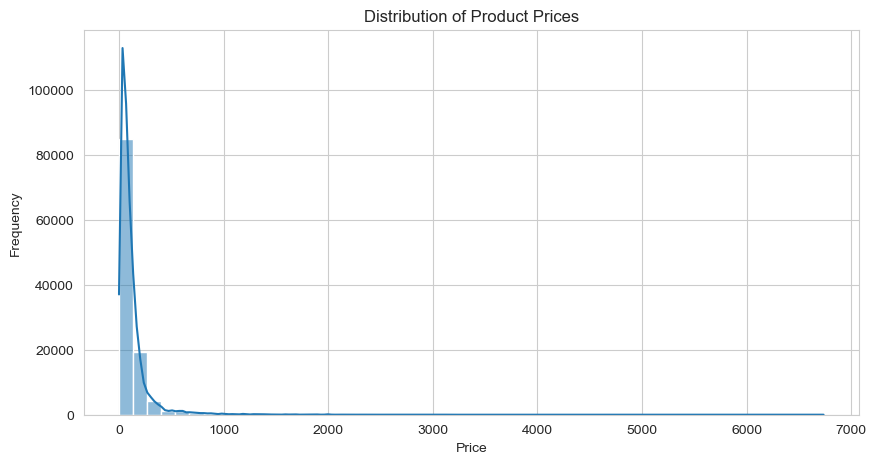

In [253]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=order_items,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

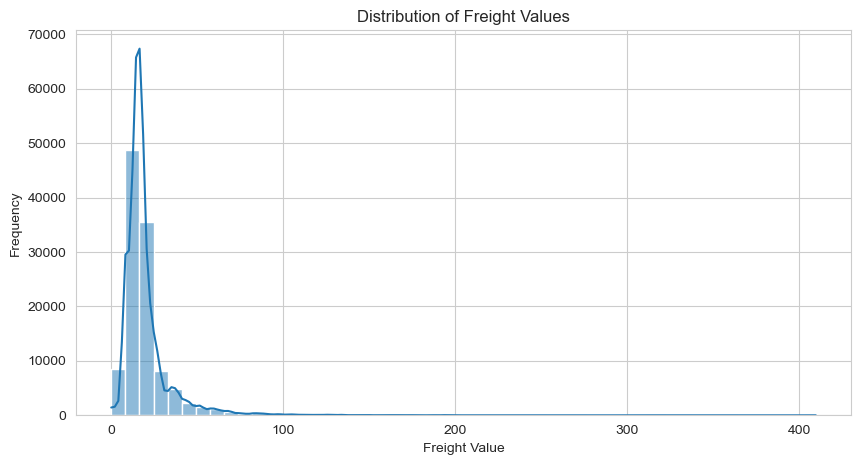

In [254]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=order_items,
    x="freight_value",
    bins=50,
    kde=True
)

plt.title("Distribution of Freight Values")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")

plt.show()

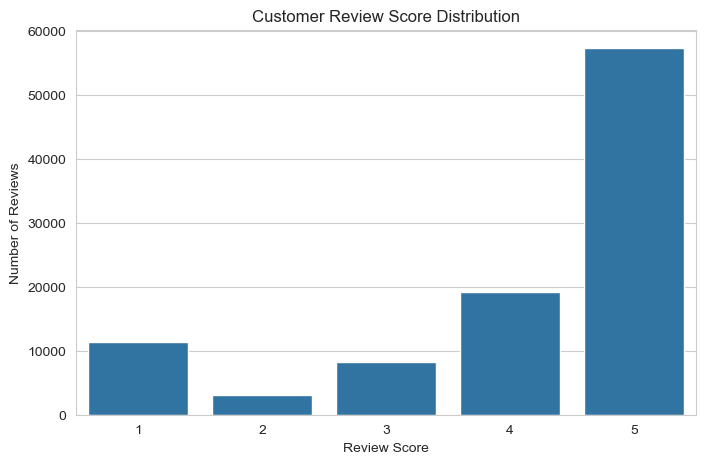

In [255]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [256]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [257]:
monthly_orders = (
    sales_data
    .groupby("purchase_month")["order_id"]
    .nunique()
)

monthly_orders

purchase_month
2016-09       3
2016-10     308
2016-12       1
2017-01     789
2017-02    1733
2017-03    2641
2017-04    2391
2017-05    3660
2017-06    3217
2017-07    3969
2017-08    4293
2017-09    4243
2017-10    4568
2017-11    7451
2017-12    5624
2018-01    7220
2018-02    6694
2018-03    7188
2018-04    6934
2018-05    6853
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: order_id, dtype: int64

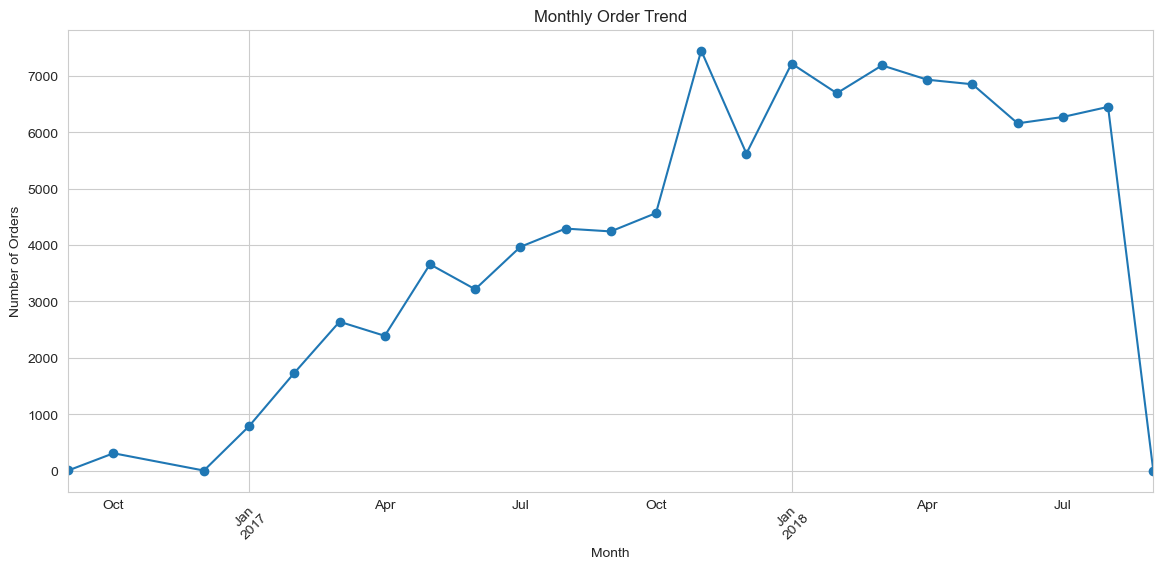

In [258]:
plt.figure(figsize=(14, 6))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [259]:
monthly_revenue = (
    sales_data
    .groupby("purchase_month")["price"]
    .sum()
)

monthly_revenue

purchase_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

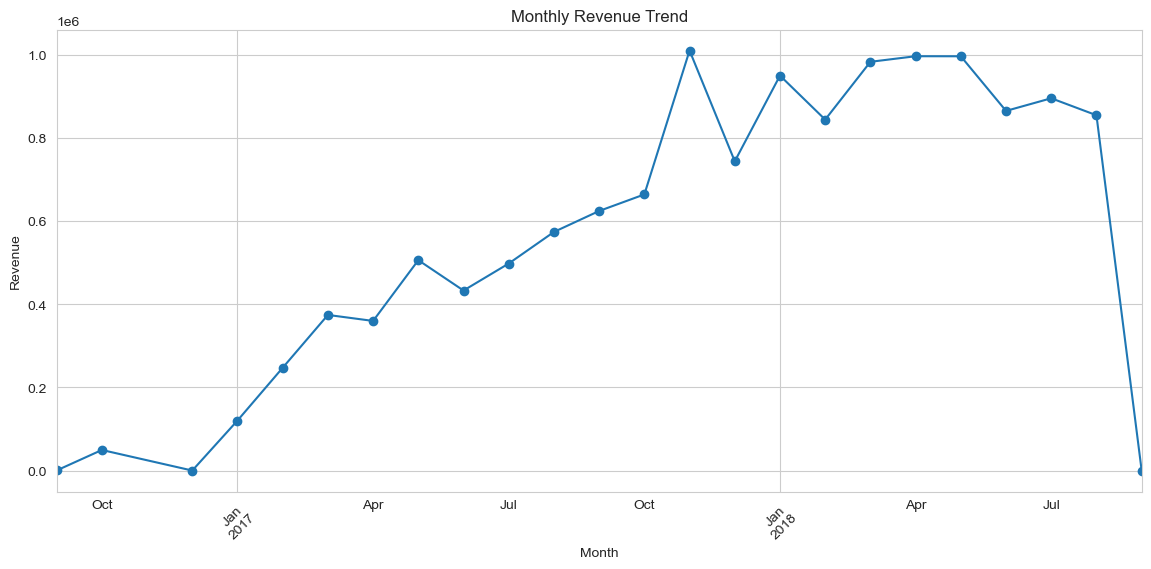

In [260]:
plt.figure(figsize=(14, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [261]:
# STEP 1: Create fresh sales_data from scratch

sales_data = orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()


# STEP 2: Merge order items

sales_data = sales_data.merge(
    order_items[
        [
            "order_id",
            "product_id",
            "price",
            "freight_value"
        ]
    ],
    on="order_id",
    how="inner"
)


# STEP 3: Merge product information

sales_data = sales_data.merge(
    products[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)


# STEP 4: Merge English category translation ONCE

sales_data = sales_data.merge(
    translation,
    on="product_category_name",
    how="left"
)


# STEP 5: Merge customer state

sales_data = sales_data.merge(
    customers[
        [
            "customer_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)


# Check columns

print(sales_data.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_id', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'customer_state']


In [262]:
top_categories = (
    sales_data
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

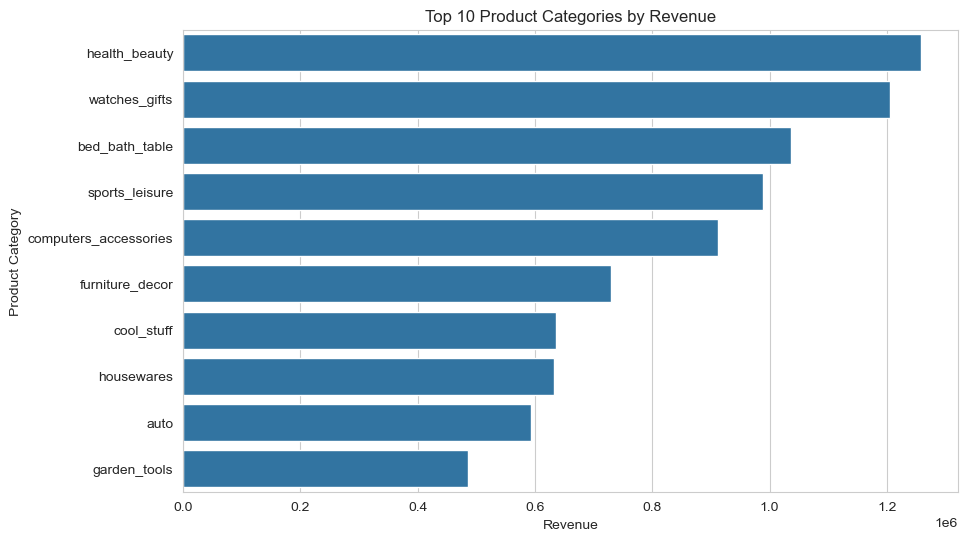

In [263]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.show()

In [264]:
category_orders = (
    sales_data
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

category_orders

product_category_name_english
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886
Name: order_id, dtype: int64

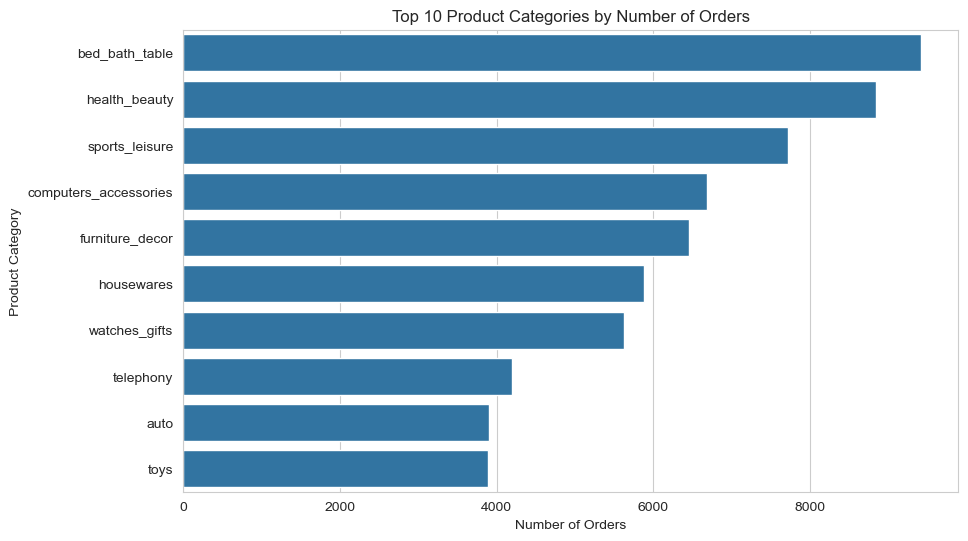

In [265]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_orders.values,
    y=category_orders.index
)

plt.title("Top 10 Product Categories by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

plt.show()

In [266]:
payment_counts = payments["payment_type"].value_counts()

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

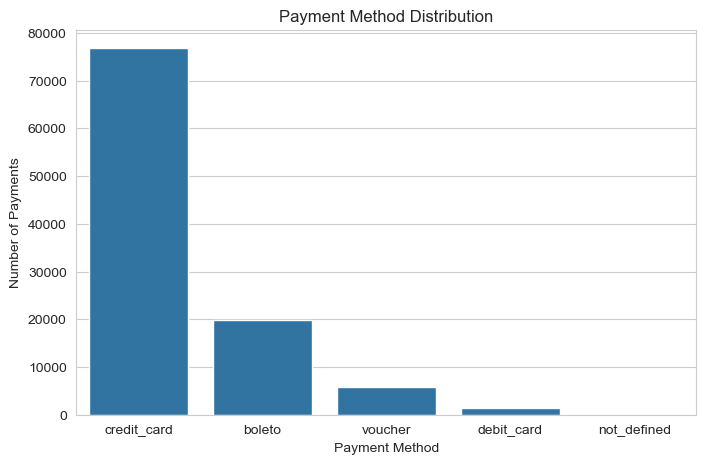

In [267]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")

plt.show()

In [268]:
payment_value = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_value


payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

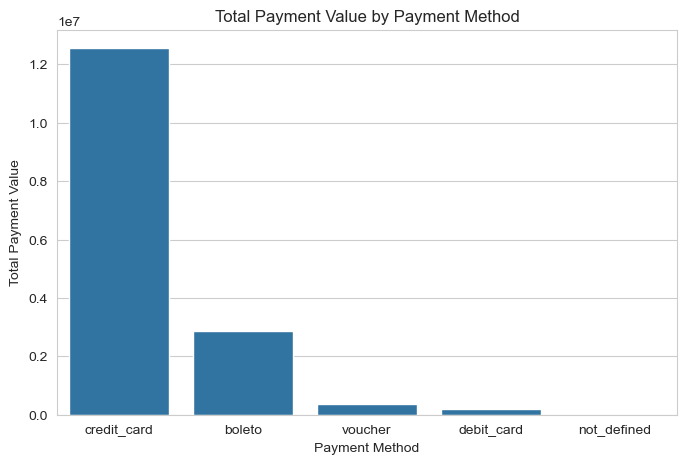

In [269]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_value.index,
    y=payment_value.values
)

plt.title("Total Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Payment Value")

plt.show()

In [270]:
review_counts = reviews["review_score"].value_counts().sort_index()

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

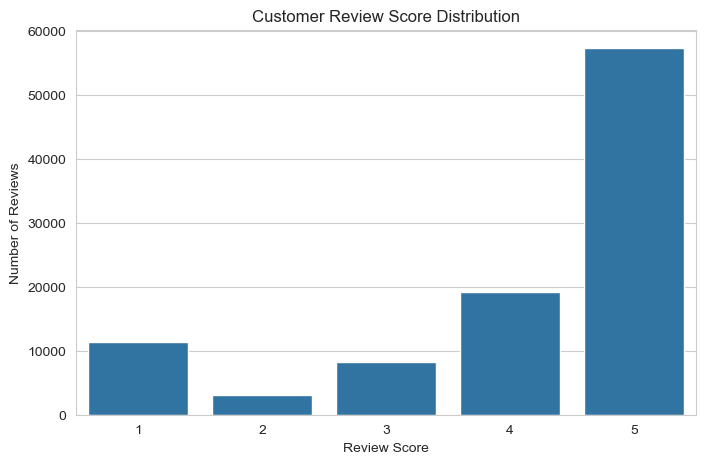

In [271]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=review_counts.index,
    y=review_counts.values
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [272]:
average_review = reviews["review_score"].mean()

print("Average Review Score:", round(average_review, 2))

Average Review Score: 4.09


In [273]:
sales_data["delivery_days"] = (
    sales_data["order_delivered_customer_date"]
    - sales_data["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [274]:
sales_data["estimated_delivery_days"] = (
    sales_data["order_estimated_delivery_date"]
    - sales_data["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [275]:
sales_data["delivery_difference"] = (
    sales_data["order_delivered_customer_date"]
    - sales_data["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [276]:
sales_data[
    [
        "order_id",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_difference"
    ]
].head()

,order_id,delivery_days,estimated_delivery_days,delivery_difference
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,-9.238171


In [277]:
sales_data["delivery_days"].describe()

count    110196.000000
mean         12.472631
std           9.445655
min           0.533414
25%           6.736262
50%          10.184282
75%          15.541097
max         209.628611
Name: delivery_days, dtype: float64

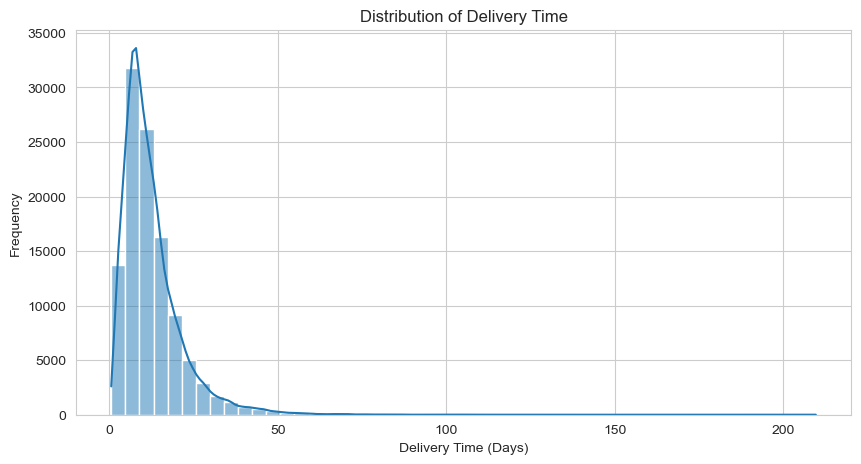

In [278]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=sales_data,
    x="delivery_days",
    bins=50,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

plt.show()

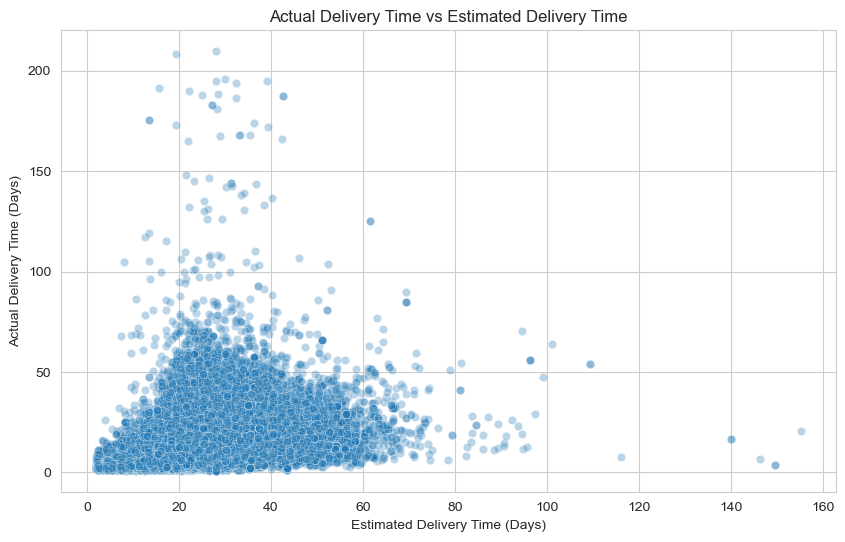

In [279]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sales_data,
    x="estimated_delivery_days",
    y="delivery_days",
    alpha=0.3
)

plt.title("Actual Delivery Time vs Estimated Delivery Time")
plt.xlabel("Estimated Delivery Time (Days)")
plt.ylabel("Actual Delivery Time (Days)")

plt.show()

In [280]:
sales_data["delivery_status"] = np.where(
    sales_data["delivery_difference"] < 0,
    "Early",
    np.where(
        sales_data["delivery_difference"] == 0,
        "On Time",
        "Late"
    )
)

In [281]:
delivery_status_counts = sales_data["delivery_status"].value_counts()

delivery_status_counts

delivery_status
Early    101481
Late      11169
Name: count, dtype: int64

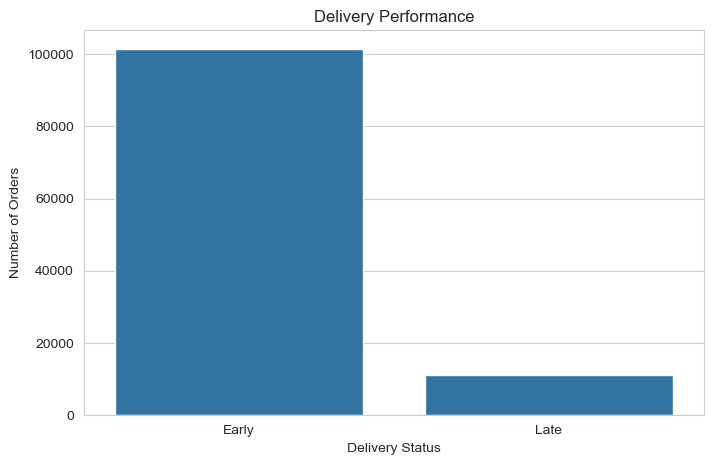

In [282]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=delivery_status_counts.index,
    y=delivery_status_counts.values
)

plt.title("Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()

In [283]:
review_by_order = (
    reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

review_by_order.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [284]:
sales_data = sales_data.merge(
    review_by_order,
    on="order_id",
    how="left"
)

In [285]:
sales_data[
    [
        "order_id",
        "delivery_days",
        "delivery_status",
        "review_score"
    ]
].head()

,order_id,delivery_days,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,Early,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,Early,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,Early,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,Early,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,Early,5.0


In [286]:
sales_data["delivery_bucket"] = pd.cut(
    sales_data["delivery_days"],
    bins=[0, 3, 7, 14, 30, 60, 120, np.inf],
    labels=[
        "0-3 days",
        "4-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "61-120 days",
        "120+ days"
    ]
)

In [287]:
delivery_review_avg = (
    sales_data
    .groupby(
        "delivery_bucket",
        observed=True
    )["review_score"]
    .mean()
)

delivery_review_avg

delivery_bucket
0-3 days       4.408909
4-7 days       4.325874
8-14 days      4.224854
15-30 days     3.899752
31-60 days     2.246454
61-120 days    2.027675
120+ days      3.043478
Name: review_score, dtype: float64

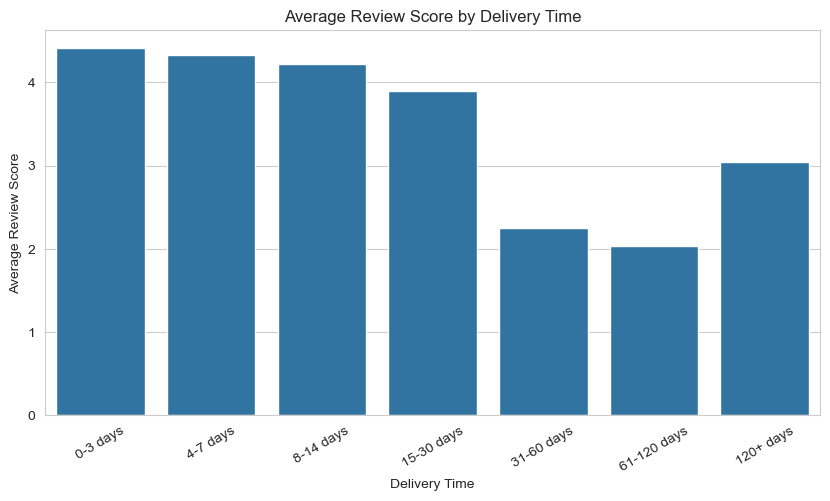

In [288]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=delivery_review_avg.index,
    y=delivery_review_avg.values
)

plt.title("Average Review Score by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Review Score")

plt.xticks(rotation=30)

plt.show()

In [289]:
delivery_review_status = (
    sales_data
    .groupby("delivery_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

delivery_review_status

delivery_status
Early    4.211417
Late     2.377337
Name: review_score, dtype: float64

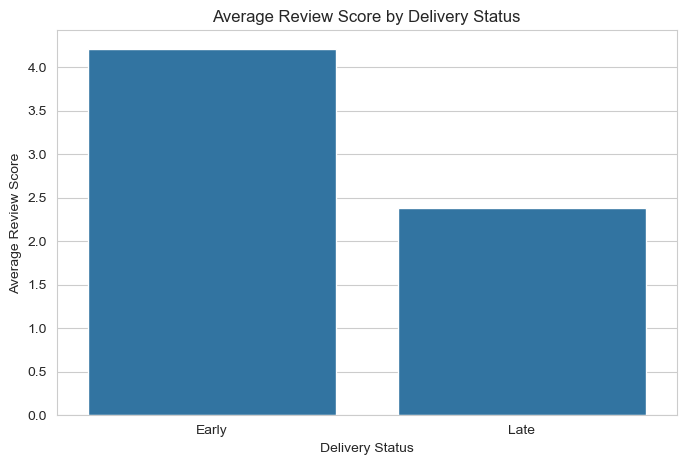

In [290]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=delivery_review_status.index,
    y=delivery_review_status.values
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.show()

In [291]:
state_revenue = (
    sales_data
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

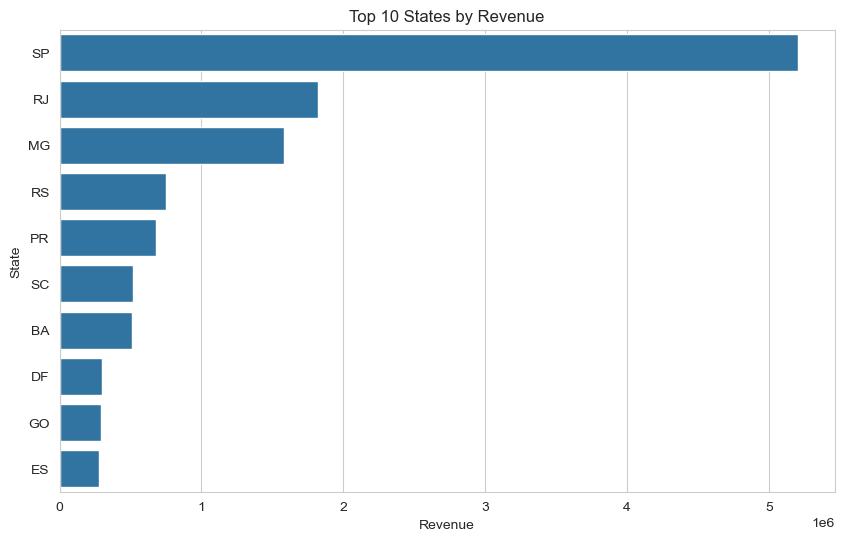

In [292]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_revenue.head(10).values,
    y=state_revenue.head(10).index
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.show()

In [293]:
state_orders = (
    sales_data
    .groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

state_orders.head(10)

customer_state
SP    41375
RJ    12762
MG    11544
RS     5432
PR     4998
SC     3612
BA     3358
DF     2125
ES     2025
GO     2007
Name: order_id, dtype: int64

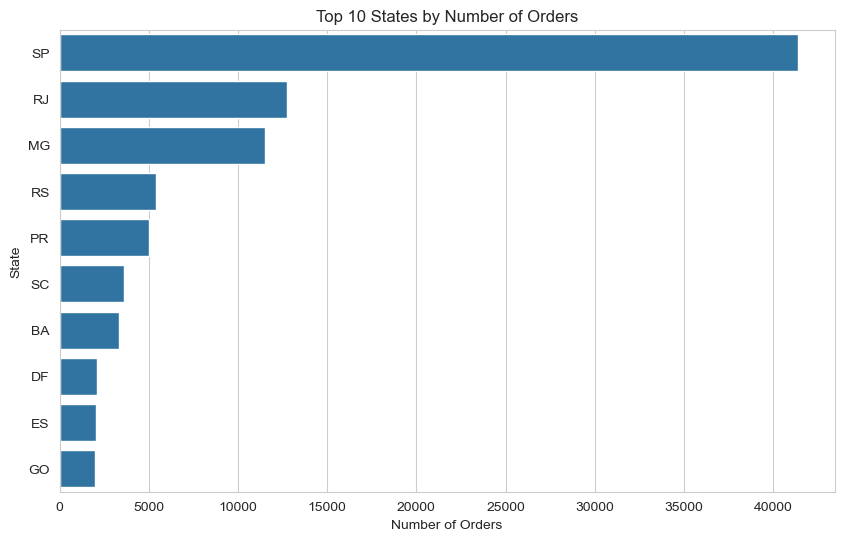

In [294]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_orders.head(10).values,
    y=state_orders.head(10).index
)

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.show()

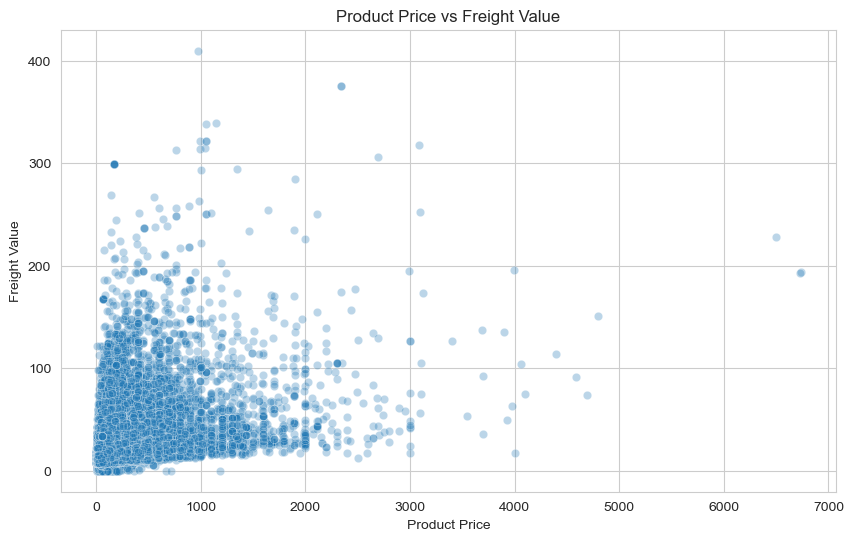

In [295]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=order_items,
    x="price",
    y="freight_value",
    alpha=0.3
)

plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")

plt.show()

In [296]:
correlation_data = sales_data[
    [
        "price",
        "freight_value",
        "delivery_days",
        "estimated_delivery_days",
        "delivery_difference",
        "review_score"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,price,freight_value,delivery_days,estimated_delivery_days,delivery_difference,review_score
price,1.000000,0.414204,0.062390,0.071168,-0.003769,-0.004081
freight_value,0.414204,1.000000,0.214687,0.274591,-0.040399,-0.036363
delivery_days,0.062390,0.214687,1.000000,0.382980,0.596820,-0.304927
estimated_delivery_days,0.071168,0.274591,0.382980,1.000000,-0.512630,-0.063776
delivery_difference,-0.003769,-0.040399,0.596820,-0.512630,1.000000,-0.228951
review_score,-0.004081,-0.036363,-0.304927,-0.063776,-0.228951,1.000000


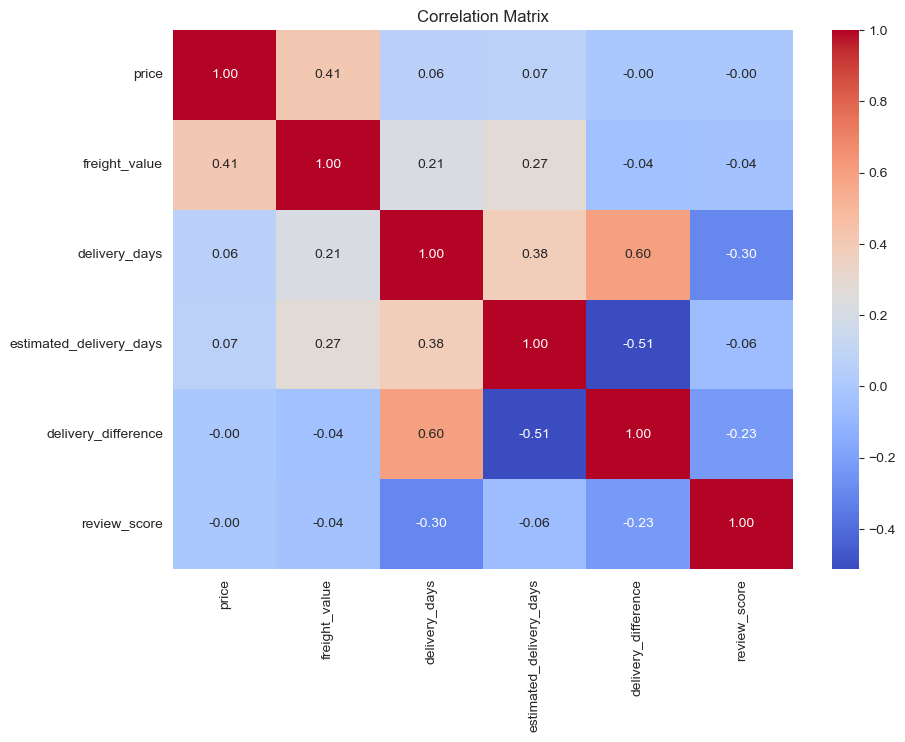

In [297]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [298]:
print("===== E-COMMERCE EDA SUMMARY =====")

print(
    "Total Orders:",
    orders["order_id"].nunique()
)

print(
    "Total Customers:",
    customers["customer_unique_id"].nunique()
)

print(
    "Total Products:",
    products["product_id"].nunique()
)

print(
    "Total Revenue:",
    round(order_items["price"].sum(), 2)
)

print(
    "Average Product Price:",
    round(order_items["price"].mean(), 2)
)

print(
    "Average Review Score:",
    round(reviews["review_score"].mean(), 2)
)

print(
    "Average Delivery Time:",
    round(sales_data["delivery_days"].mean(), 2),
    "days"
)

===== E-COMMERCE EDA SUMMARY =====
Total Orders: 99441
Total Customers: 96096
Total Products: 32951
Total Revenue: 13591643.7
Average Product Price: 120.65
Average Review Score: 4.09
Average Delivery Time: 12.47 days


In [300]:
sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [301]:
sales_data[["order_purchase_timestamp", "purchase_month"]].head()

,order_purchase_timestamp,purchase_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


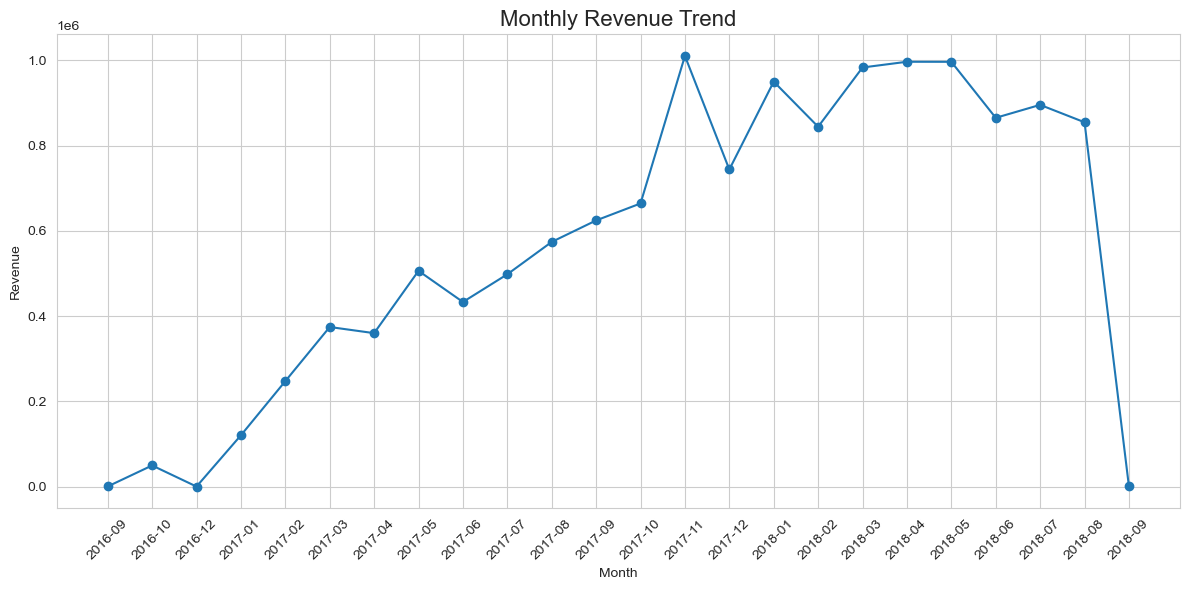

In [302]:
# Monthly Revenue Trend

monthly_revenue = (
    
    sales_data
    .groupby("purchase_month")["price"]
    .sum()
)


plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

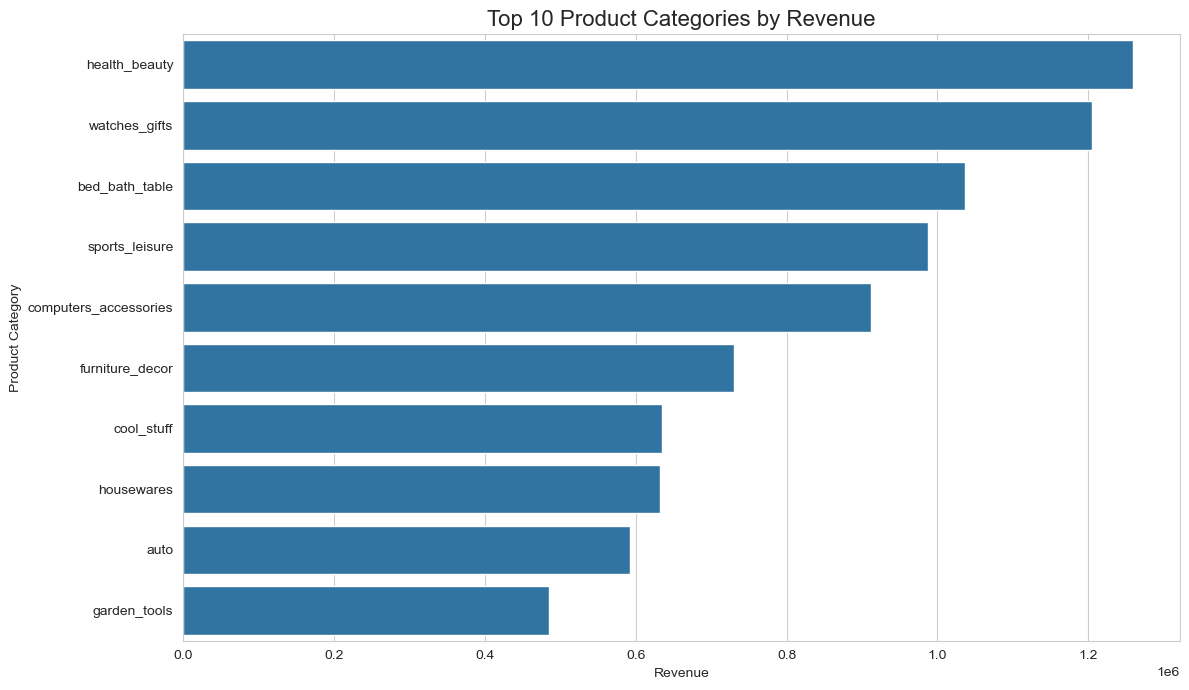

In [303]:
# Top 10 Product Categories by Revenue

top_categories = (
    sales_data
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

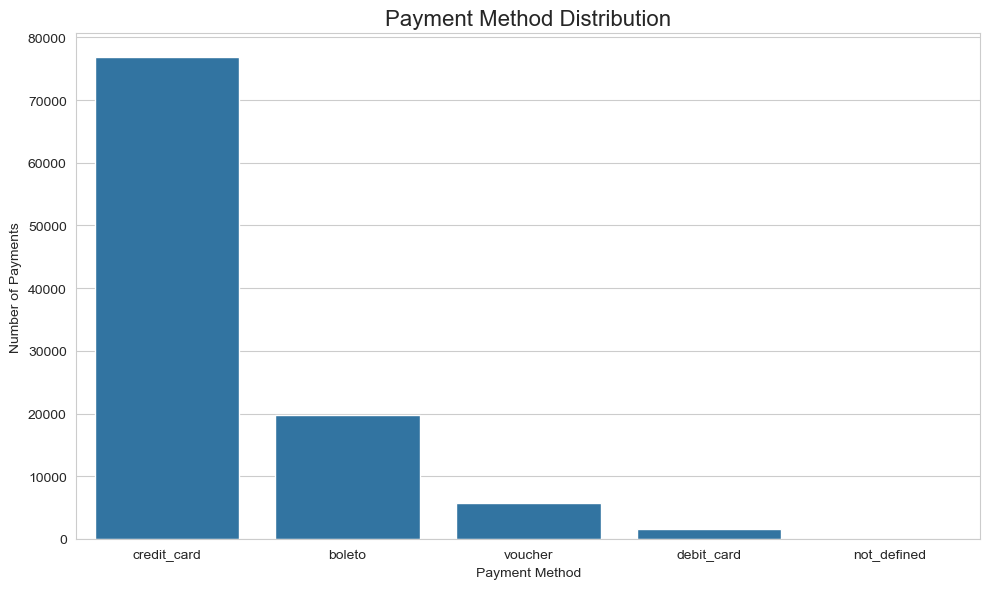

In [304]:
# Payment Method Distribution

payment_counts = payments["payment_type"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Distribution", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")

plt.tight_layout()
plt.show()

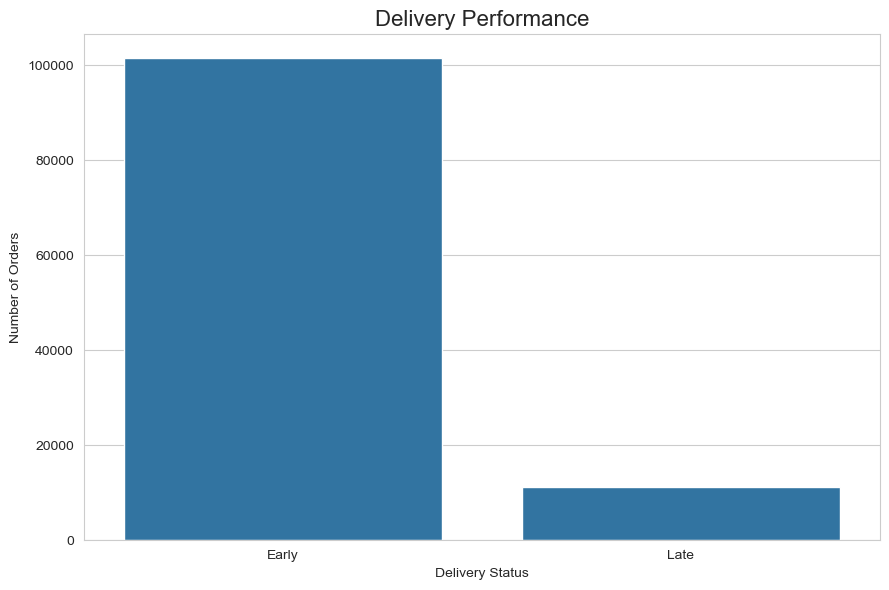

In [305]:
# Delivery Performance: Early vs On Time vs Late

sales_data["delivery_status"] = np.where(
    sales_data["delivery_difference"] < 0,
    "Early",
    np.where(
        sales_data["delivery_difference"] == 0,
        "On Time",
        "Late"
    )
)

delivery_status_counts = (
    sales_data["delivery_status"]
    .value_counts()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=delivery_status_counts.index,
    y=delivery_status_counts.values
)

plt.title("Delivery Performance", fontsize=16)
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

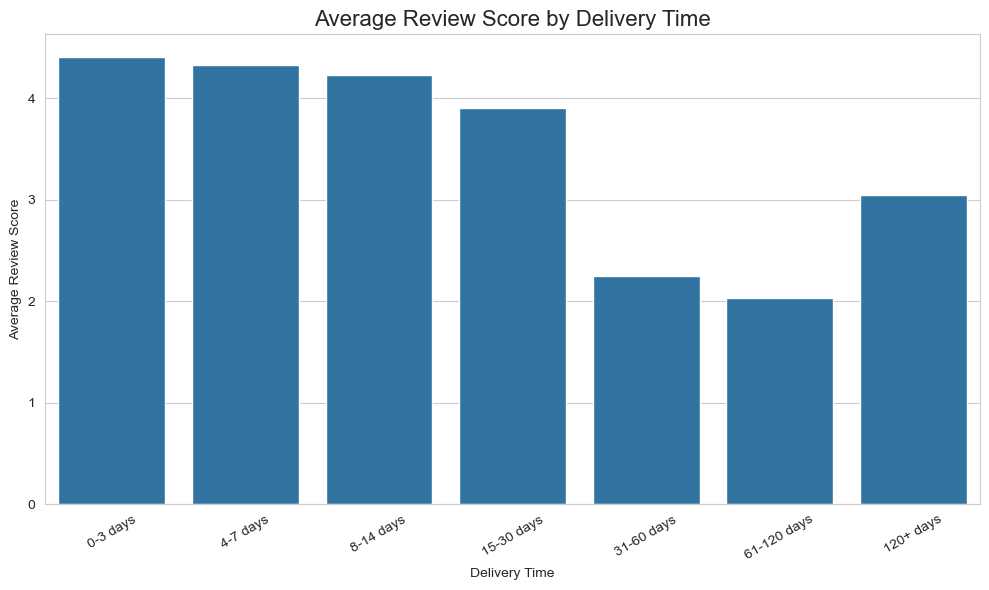

In [306]:
# Average Review Score by Delivery Time

sales_data["delivery_bucket"] = pd.cut(
    sales_data["delivery_days"],
    bins=[0, 3, 7, 14, 30, 60, 120, np.inf],
    labels=[
        "0-3 days",
        "4-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "61-120 days",
        "120+ days"
    ]
)

delivery_review_avg = (
    sales_data
    .groupby(
        "delivery_bucket",
        observed=True
    )["review_score"]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=delivery_review_avg.index,
    y=delivery_review_avg.values
)

plt.title(
    "Average Review Score by Delivery Time",
    fontsize=16
)

plt.xlabel("Delivery Time")
plt.ylabel("Average Review Score")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()